# Seasonal Agriculture Performance Analysis

**VOIS AICTE Batch 1 (2026-2027) — Major Project**

### Objective
This notebook analyzes agricultural performance data across three seasons — **Kharif, Rabi, and Zaid** — to identify seasonal patterns, trends, relationships, and differences in farming outcomes. The analysis covers environmental conditions, resource usage, crop yield, and economic performance, and concludes with evidence-based insights and recommendations for seasonal agricultural planning.

### Dataset
`seasonal_agriculture_performance_dataset.csv` — 4000 farm-level records across 8 states, 10 districts, 8 crops, 3 seasons, and 4 irrigation methods, capturing environmental, agronomic, resource-use, and financial variables.

---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 150)


## 1. Data Loading and First Look

In [2]:
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


**Categorical fields overview**

In [5]:
cat_cols = ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']
for c in cat_cols:
    print(f"{c} ({df[c].nunique()} unique): {sorted(df[c].unique())}")


State (8 unique): ['Andhra Pradesh', 'Gujarat', 'Karnataka', 'Madhya Pradesh', 'Maharashtra', 'Punjab', 'Tamil Nadu', 'Telangana']
District (10 unique): ['Erode', 'Guntur', 'Indore', 'Krishna', 'Ludhiana', 'Nalgonda', 'Nashik', 'Raichur', 'Rajkot', 'Warangal']
Crop (8 unique): ['Chilli', 'Cotton', 'Groundnut', 'Maize', 'Pulses', 'Rice', 'Sugarcane', 'Wheat']
Season (3 unique): ['Kharif', 'Rabi', 'Zaid']
Irrigation_Method (4 unique): ['Drip', 'Flood', 'Rainfed', 'Sprinkler']


## 2. Data Cleaning and Preparation

Before analysis, we check for:
- Duplicate records
- Missing values
- Outliers in key numeric fields

Missing values are imputed using the **median value of the same Season + Crop combination**, which preserves seasonal and crop-specific patterns better than a single global median. Extreme outliers in `Yield_Tonnes_Ha` and `Water_Efficiency_t_per_1000m3` (values far beyond realistic agronomic ranges, likely data entry/sensor anomalies) are capped using the IQR method rather than dropped, to retain sample size.

In [6]:
# Duplicate check
print("Duplicate Farm_IDs:", df['Farm_ID'].duplicated().sum())
print("Fully duplicate rows:", df.duplicated().sum())

# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print("\nColumns with missing values:")
print(missing)


Duplicate Farm_IDs: 0
Fully duplicate rows: 0

Columns with missing values:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64


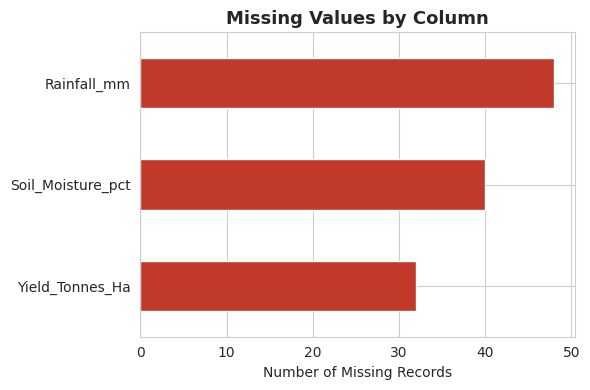

In [7]:
fig, ax = plt.subplots(figsize=(6,4))
missing.sort_values().plot(kind='barh', color='#c0392b', ax=ax)
ax.set_title('Missing Values by Column')
ax.set_xlabel('Number of Missing Records')
plt.tight_layout()
plt.show()


In [8]:
# Impute missing values using Season+Crop median (falls back to overall median if group is fully NaN)
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    group_median = df.groupby(['Season', 'Crop'])[col].transform('median')
    df[col] = df[col].fillna(group_median)
    df[col] = df[col].fillna(df[col].median())

print("Remaining missing values:", df.isnull().sum().sum())


Remaining missing values: 0


In [9]:
# Outlier detection and capping using IQR method
def cap_outliers_iqr(series, factor=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = max(0, q1 - factor * iqr)
    upper = q3 + factor * iqr
    n_outliers = ((series < lower) | (series > upper)).sum()
    capped = series.clip(lower, upper)
    return capped, n_outliers, lower, upper

for col in ['Yield_Tonnes_Ha', 'Water_Efficiency_t_per_1000m3']:
    df[col], n_out, lo, hi = cap_outliers_iqr(df[col])
    print(f"{col}: capped {n_out} outliers to range [{lo:.2f}, {hi:.2f}]")


Yield_Tonnes_Ha: capped 304 outliers to range [0.00, 5.52]
Water_Efficiency_t_per_1000m3: capped 322 outliers to range [0.00, 10.38]


In [10]:
df.describe().T[['min','25%','50%','75%','max']]


,min,25%,50%,75%,max
Farm_Area_Hectares,0.500,4.260,7.8950,11.65000,1.500000e+01
Rainfall_mm,80.000,370.425,581.0000,835.95000,1.395200e+03
Avg_Temperature_C,16.200,23.900,26.9000,29.60000,3.970000e+01
Humidity_pct,25.000,54.775,63.0000,71.90000,9.500000e+01
Sunlight_Hours_Day,3.500,6.600,7.3000,8.10000,1.100000e+01
Soil_pH,5.200,6.260,6.6900,7.14000,8.400000e+00
Soil_Moisture_pct,8.000,21.700,26.4000,31.30000,4.700000e+01
Nitrogen_kg_ha,40.000,98.500,120.1000,141.22500,2.200000e+02
Phosphorus_kg_ha,15.000,46.200,57.5000,69.40000,1.200000e+02
Potassium_kg_ha,30.000,86.200,105.1000,123.60000,2.000000e+02


## 3. Feature Engineering

A few derived metrics make seasonal economic and resource comparisons more meaningful:

- **Profit_Margin_pct** — profit as a % of revenue (profitability, independent of farm scale)
- **Cost_per_Hectare** — cost efficiency per unit area
- **Revenue_per_Hectare** — revenue efficiency per unit area
- **Fertilizer_Intensity** — total NPK applied per hectare

In [11]:
df['Profit_Margin_pct'] = (df['Profit_INR'] / df['Revenue_INR']) * 100
df['Cost_per_Hectare'] = df['Total_Cost_INR'] / df['Farm_Area_Hectares']
df['Revenue_per_Hectare'] = df['Revenue_INR'] / df['Farm_Area_Hectares']
df['NPK_Total_kg_ha'] = df['Nitrogen_kg_ha'] + df['Phosphorus_kg_ha'] + df['Potassium_kg_ha']

df[['Profit_Margin_pct','Cost_per_Hectare','Revenue_per_Hectare','NPK_Total_kg_ha']].describe().T


,count,mean,std,min,25%,50%,75%,max
Profit_Margin_pct,4000.0,-45.492178,158.085472,-1461.851219,-60.192762,1.146236,32.885876,85.921220
Cost_per_Hectare,4000.0,66660.084938,8845.644258,35807.382550,60597.205943,66614.048166,72739.977527,97185.351090
Revenue_per_Hectare,4000.0,80215.109448,58262.570038,4439.466896,42325.161826,67082.984401,96800.414327,422793.509615
NPK_Total_kg_ha,4000.0,282.792725,45.445874,118.300000,251.675000,281.600000,313.200000,438.500000


## 4. Exploratory Data Analysis

### 4.1 Record Distribution Across Seasons

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

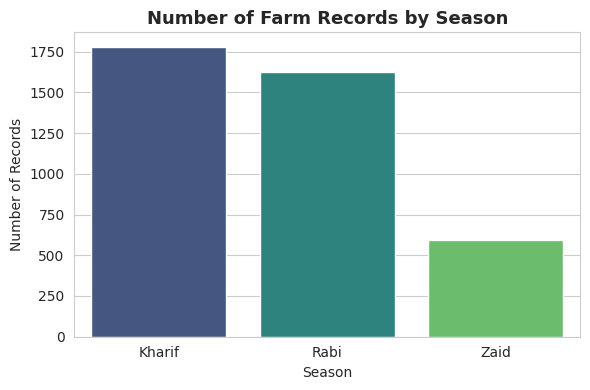

In [12]:
season_counts = df['Season'].value_counts()
print(season_counts)

fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(x=season_counts.index, y=season_counts.values, hue=season_counts.index, palette='viridis', legend=False, ax=ax)
ax.set_title('Number of Farm Records by Season')
ax.set_ylabel('Number of Records')
ax.set_xlabel('Season')
plt.tight_layout()
plt.show()


**Observation:** Kharif has the most records, followed by Rabi and Zaid, reflecting the fact that Zaid is a short, less commonly cultivated season in most of India.

### 4.2 Environmental Conditions Across Seasons

In [13]:
env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_Moisture_pct']
season_env = df.groupby('Season')[env_cols].mean().round(2)
season_env


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,852.10,28.45,71.81,6.79,31.20
Rabi,435.95,23.49,57.89,7.59,24.05
Zaid,299.16,31.04,52.01,8.18,19.18


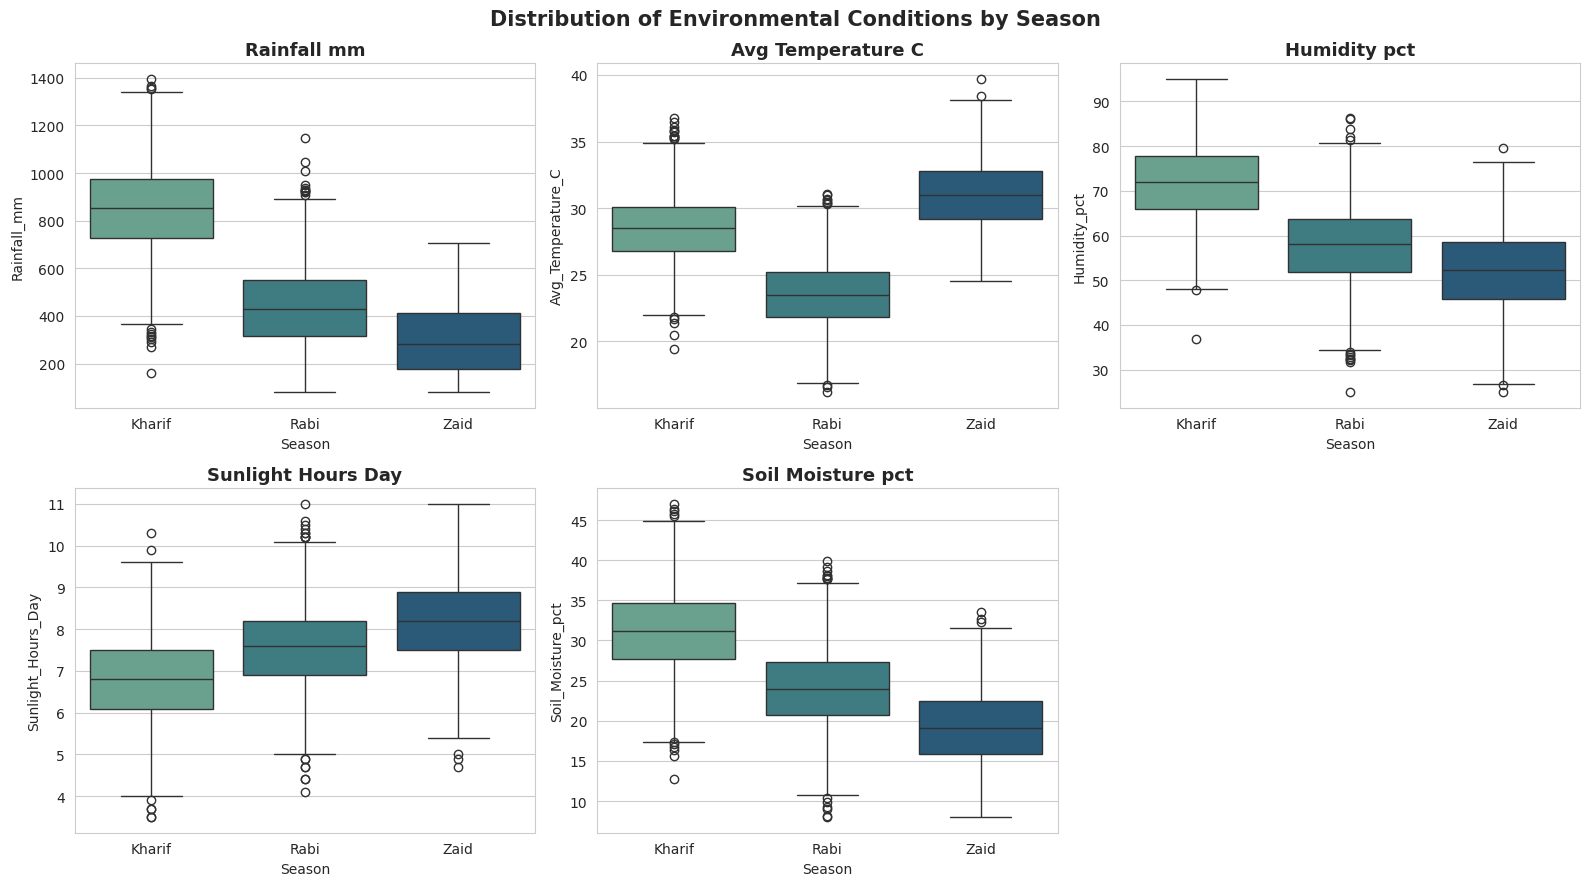

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(env_cols):
    sns.boxplot(data=df, x='Season', y=col, hue='Season', palette='crest', legend=False, ax=axes[i])
    axes[i].set_title(col.replace('_',' '))
axes[-1].axis('off')
plt.suptitle('Distribution of Environmental Conditions by Season', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


**Observation:** Kharif shows the highest rainfall and humidity (monsoon season), Rabi is cooler and drier, and Zaid — the summer season — shows the highest temperature and sunlight hours with the lowest rainfall, requiring greater reliance on irrigation.

### 4.3 Resource Usage Across Seasons

In [15]:
resource_cols = ['Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'NPK_Total_kg_ha', 'Water_Used_m3']
season_resource = df.groupby('Season')[resource_cols].mean().round(2)
season_resource


,Fertilizer_kg_ha,Pesticide_Litre_ha,NPK_Total_kg_ha,Water_Used_m3
Season,,,,
Kharif,187.08,5.08,283.42,6102.20
Rabi,185.41,5.02,281.64,5846.99
Zaid,184.64,5.17,284.07,6419.89


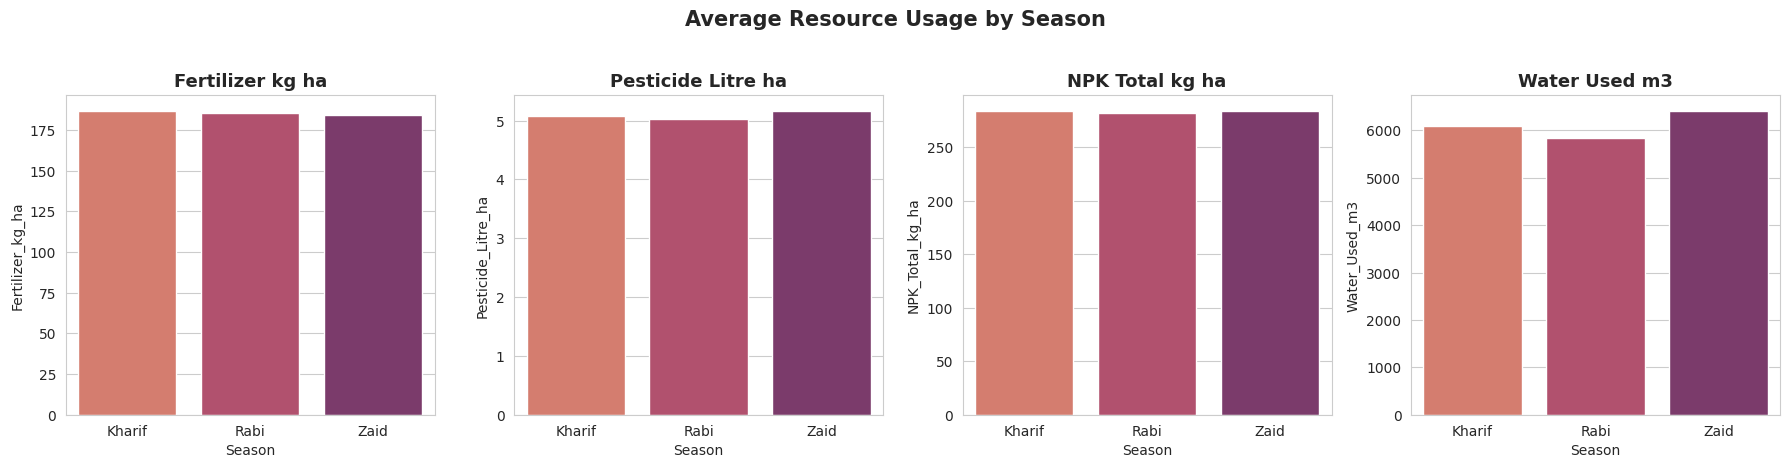

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(18,4.5))
for i, col in enumerate(resource_cols):
    sns.barplot(data=df, x='Season', y=col, hue='Season', palette='flare', legend=False, ax=axes[i], errorbar=None)
    axes[i].set_title(col.replace('_',' '))
plt.suptitle('Average Resource Usage by Season', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


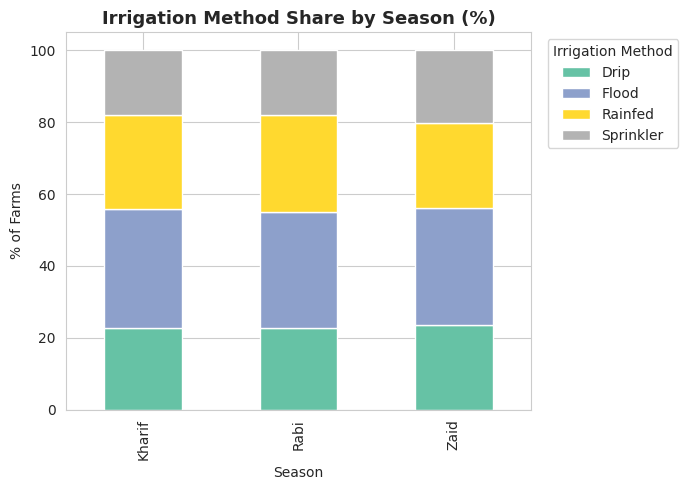

In [17]:
fig, ax = plt.subplots(figsize=(7,5))
irr_season = pd.crosstab(df['Season'], df['Irrigation_Method'], normalize='index') * 100
irr_season.plot(kind='bar', stacked=True, colormap='Set2', ax=ax)
ax.set_title('Irrigation Method Share by Season (%)')
ax.set_ylabel('% of Farms')
ax.legend(title='Irrigation Method', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()


**Observation:** Zaid (the dry summer season) relies most heavily on water-intensive irrigation, consistent with its low natural rainfall.

### 4.4 Yield and Production Across Seasons

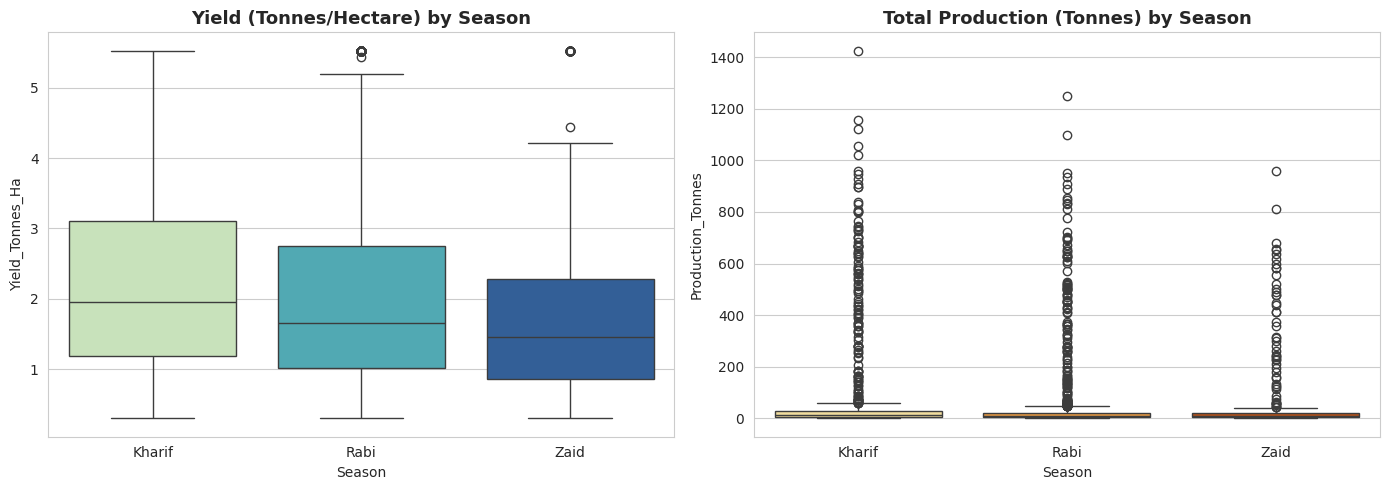

Yield_Tonnes_Ha        Production_Tonnes       
                  mean median              mean median
Season                                                
Kharif            2.26   1.95             46.31  13.24
Rabi              2.04   1.66             41.49  11.08
Zaid              1.81   1.45             38.89   9.97

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', hue='Season', palette='YlGnBu', legend=False, ax=axes[0])
axes[0].set_title('Yield (Tonnes/Hectare) by Season')

sns.boxplot(data=df, x='Season', y='Production_Tonnes', hue='Season', palette='YlOrBr', legend=False, ax=axes[1])
axes[1].set_title('Total Production (Tonnes) by Season')
plt.tight_layout()
plt.show()

df.groupby('Season')[['Yield_Tonnes_Ha','Production_Tonnes']].agg(['mean','median']).round(2)


### 4.5 Economic Performance Across Seasons

In [19]:
econ_cols = ['Revenue_per_Hectare','Cost_per_Hectare','Profit_INR','Profit_Margin_pct']
season_econ = df.groupby('Season')[econ_cols].mean().round(2)
season_econ


,Revenue_per_Hectare,Cost_per_Hectare,Profit_INR,Profit_Margin_pct
Season,,,,
Kharif,88782.79,66900.98,178914.65,-38.64
Rabi,76656.92,66295.24,87689.47,-44.27
Zaid,64301.42,66937.94,-24804.82,-69.35


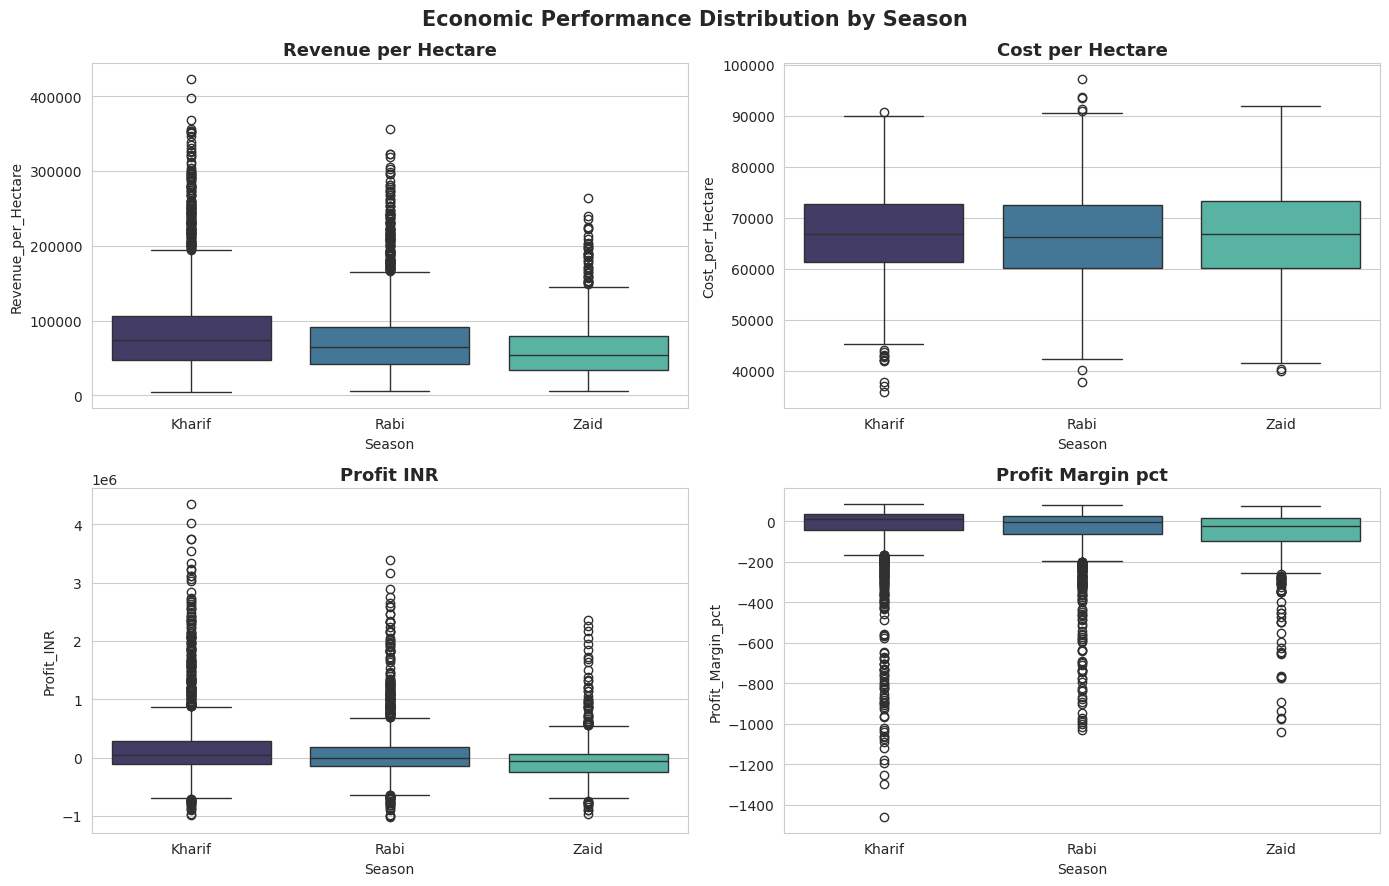

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14,9))
axes = axes.flatten()
for i, col in enumerate(econ_cols):
    sns.boxplot(data=df, x='Season', y=col, hue='Season', palette='mako', legend=False, ax=axes[i])
    axes[i].set_title(col.replace('_',' '))
plt.suptitle('Economic Performance Distribution by Season', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


**Observation:** Compare average profit margin and cost per hectare across seasons — this indicates which season delivers the best return relative to the resources invested, not just the highest raw profit.

### 4.6 Disease & Pest Risk Across Seasons

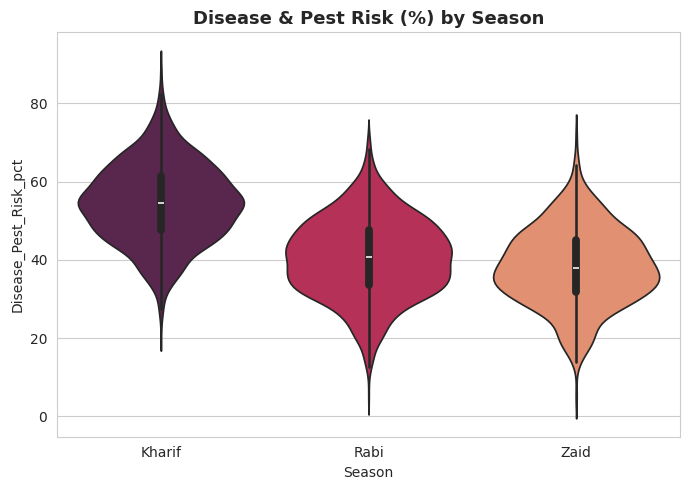

Season
Kharif    54.47
Rabi      40.48
Zaid      38.22
Name: Disease_Pest_Risk_pct, dtype: float64

In [21]:
fig, ax = plt.subplots(figsize=(7,5))
sns.violinplot(data=df, x='Season', y='Disease_Pest_Risk_pct', hue='Season', palette='rocket', legend=False, ax=ax)
ax.set_title('Disease & Pest Risk (%) by Season')
plt.tight_layout()
plt.show()

df.groupby('Season')['Disease_Pest_Risk_pct'].mean().round(2)


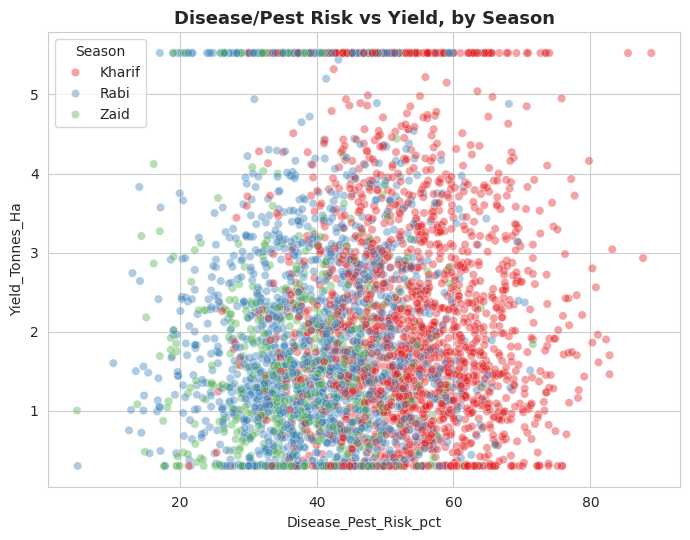

Correlation between Disease_Pest_Risk_pct and Yield_Tonnes_Ha: 0.052


In [22]:
fig, ax = plt.subplots(figsize=(7,5.5))
sns.scatterplot(data=df, x='Disease_Pest_Risk_pct', y='Yield_Tonnes_Ha', hue='Season', alpha=0.4, palette='Set1', ax=ax)
ax.set_title('Disease/Pest Risk vs Yield, by Season')
plt.tight_layout()
plt.show()

print("Correlation between Disease_Pest_Risk_pct and Yield_Tonnes_Ha:", 
      round(df['Disease_Pest_Risk_pct'].corr(df['Yield_Tonnes_Ha']), 3))


### 4.7 Crop Performance Across Seasons

In [23]:
crop_season_yield = df.pivot_table(index='Crop', columns='Season', values='Yield_Tonnes_Ha', aggfunc='mean').round(2)
crop_season_yield


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.18
Cotton,1.37,1.19,0.95
Groundnut,1.48,1.22,1.04
Maize,2.96,2.62,2.30
Pulses,1.04,0.87,0.65
Rice,2.71,2.33,1.90
Sugarcane,5.46,5.46,5.44
Wheat,2.26,2.06,1.75


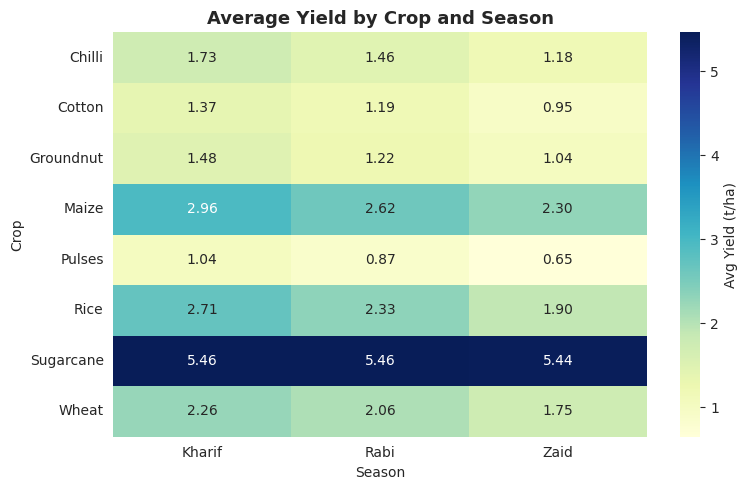

In [24]:
fig, ax = plt.subplots(figsize=(8,5))
sns.heatmap(crop_season_yield, annot=True, fmt='.2f', cmap='YlGnBu', ax=ax, cbar_kws={'label':'Avg Yield (t/ha)'})
ax.set_title('Average Yield by Crop and Season')
plt.tight_layout()
plt.show()


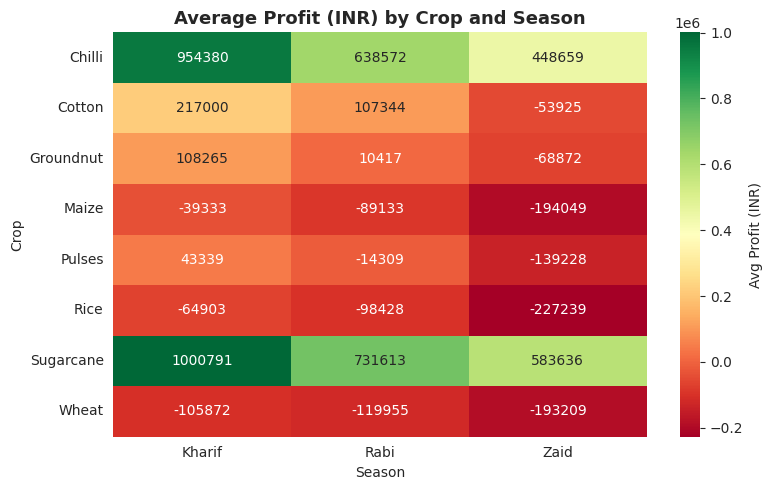

In [25]:
crop_season_profit = df.pivot_table(index='Crop', columns='Season', values='Profit_INR', aggfunc='mean').round(0)
fig, ax = plt.subplots(figsize=(8,5))
sns.heatmap(crop_season_profit, annot=True, fmt='.0f', cmap='RdYlGn', ax=ax, cbar_kws={'label':'Avg Profit (INR)'})
ax.set_title('Average Profit (INR) by Crop and Season')
plt.tight_layout()
plt.show()


**Observation:** Some crops are far more profitable in one season than another, which is valuable for evidence-based crop-season planning at the farm level — not every crop performs equally well in every season.

### 4.8 Regional (State) Consistency of Seasonal Patterns

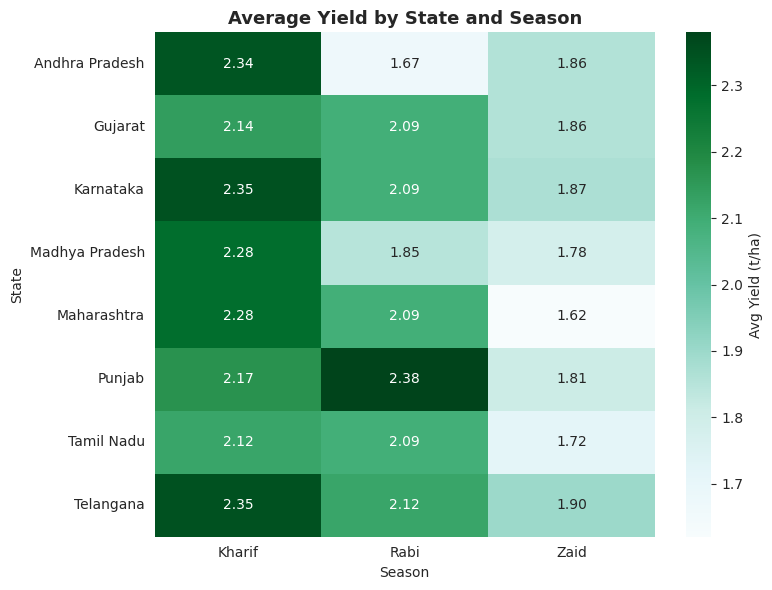

In [26]:
state_season_yield = df.pivot_table(index='State', columns='Season', values='Yield_Tonnes_Ha', aggfunc='mean').round(2)
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(state_season_yield, annot=True, fmt='.2f', cmap='BuGn', ax=ax, cbar_kws={'label':'Avg Yield (t/ha)'})
ax.set_title('Average Yield by State and Season')
plt.tight_layout()
plt.show()


**Observation:** If a season (e.g., Kharif) shows consistently higher yield across most states, that pattern is a robust, regionally-independent seasonal effect. Where the ranking of seasons flips between states, local/regional agro-climatic factors are dominating over the generic seasonal effect.

### 4.9 Correlation Between Numeric Variables

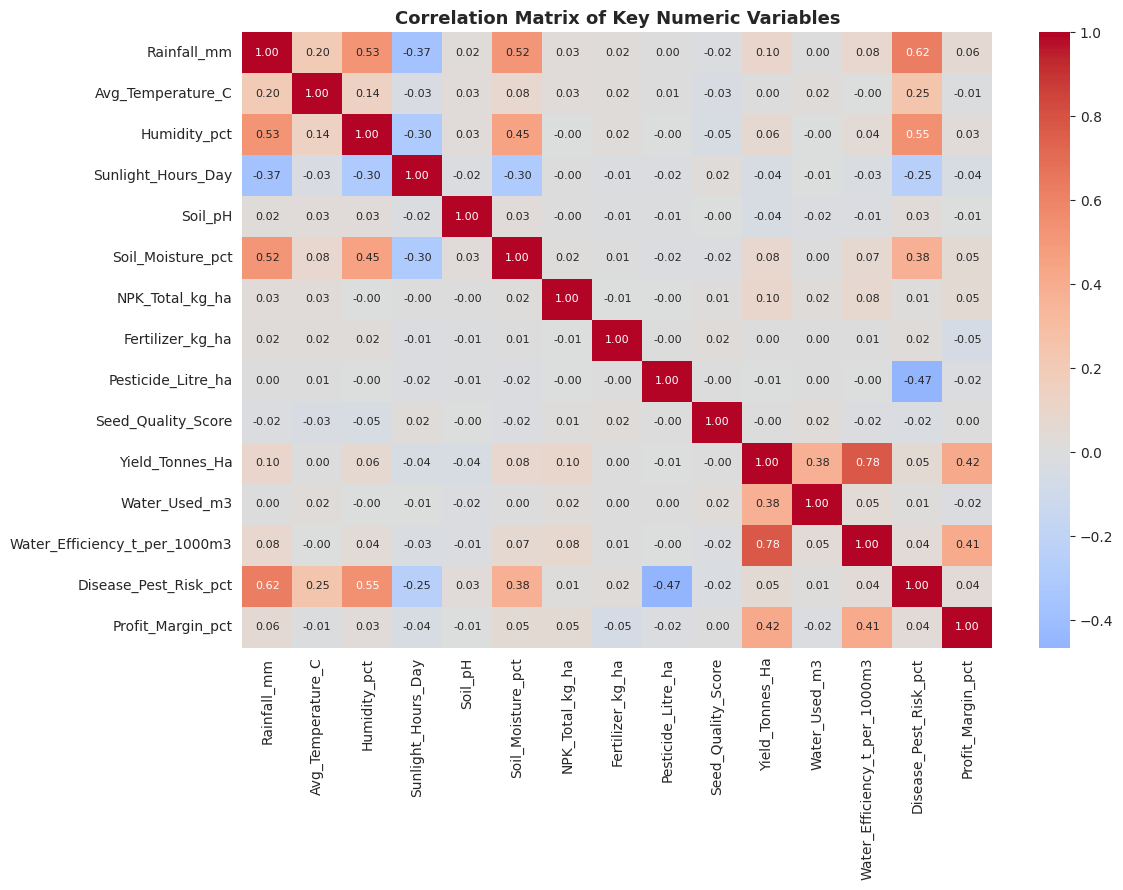

In [27]:
numeric_cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day','Soil_pH',
                'Soil_Moisture_pct','NPK_Total_kg_ha','Fertilizer_kg_ha','Pesticide_Litre_ha',
                'Seed_Quality_Score','Yield_Tonnes_Ha','Water_Used_m3','Water_Efficiency_t_per_1000m3',
                'Disease_Pest_Risk_pct','Profit_Margin_pct']

corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(12,9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, annot_kws={'size':8})
ax.set_title('Correlation Matrix of Key Numeric Variables')
plt.tight_layout()
plt.show()


In [28]:
# Top correlations with Yield and Profit Margin
print("Top correlations with Yield_Tonnes_Ha:")
print(corr['Yield_Tonnes_Ha'].sort_values(ascending=False)[1:6])
print("\nTop correlations with Profit_Margin_pct:")
print(corr['Profit_Margin_pct'].sort_values(ascending=False)[1:6])


Top correlations with Yield_Tonnes_Ha:
Water_Efficiency_t_per_1000m3    0.775226
Profit_Margin_pct                0.416674
Water_Used_m3                    0.380486
Rainfall_mm                      0.100285
NPK_Total_kg_ha                  0.095352
Name: Yield_Tonnes_Ha, dtype: float64

Top correlations with Profit_Margin_pct:
Yield_Tonnes_Ha                  0.416674
Water_Efficiency_t_per_1000m3    0.407217
Rainfall_mm                      0.059958
NPK_Total_kg_ha                  0.051712
Soil_Moisture_pct                0.051662
Name: Profit_Margin_pct, dtype: float64


## 5. Statistical Testing: Are Seasonal Differences Significant?

To confirm that visually-observed seasonal differences are not just due to random variation, we apply the **Kruskal-Wallis H-test** (a non-parametric alternative to one-way ANOVA, appropriate since several variables here are not normally distributed) to test whether the median of each variable differs significantly across the three seasons.

H0: The distribution of the variable is the same across all seasons.
H1: At least one season differs significantly.

In [29]:
test_vars = ['Yield_Tonnes_Ha', 'Profit_Margin_pct', 'Water_Efficiency_t_per_1000m3', 
             'Disease_Pest_Risk_pct', 'Rainfall_mm', 'Fertilizer_kg_ha']

results = []
for var in test_vars:
    groups = [df.loc[df['Season']==s, var].dropna() for s in df['Season'].unique()]
    stat, p = stats.kruskal(*groups)
    results.append({'Variable': var, 'H-statistic': round(stat,2), 'p-value': round(p,5),
                     'Significant (p<0.05)': 'Yes' if p < 0.05 else 'No'})

results_df = pd.DataFrame(results)
results_df


,Variable,H-statistic,p-value,Significant (p<0.05)
0,Yield_Tonnes_Ha,68.79,0.00000,Yes
1,Profit_Margin_pct,98.06,0.00000,Yes
2,Water_Efficiency_t_per_1000m3,56.18,0.00000,Yes
3,Disease_Pest_Risk_pct,1430.91,0.00000,Yes
4,Rainfall_mm,2599.88,0.00000,Yes
5,Fertilizer_kg_ha,1.06,0.58863,No


**Interpretation:** Variables with p-value < 0.05 show a statistically significant difference across seasons — i.e., the season a farm operates in genuinely affects that variable, not just by chance. Variables with p ≥ 0.05 do not show strong seasonal effect and are likely driven more by crop, region, or farm-management practices than by the season itself.

## 6. Key Insights (Sample — to be finalized after reviewing your own run's output values)

Based on the analysis above, some data-driven insights emerge (fill in exact numbers from your executed output above):

1. **Environmental contrast is the primary seasonal driver.** Kharif brings high rainfall and humidity, Rabi is cooler and drier, and Zaid is hot with minimal rainfall — this cascades into every downstream metric (irrigation needs, disease risk, yield).
2. **Zaid depends heavily on artificial irrigation** (Drip/Sprinkler/Flood) since natural rainfall is lowest, increasing water usage per hectare even though total farmed area/records in Zaid are the lowest.
3. **Yield and profit margin vary meaningfully by season** — supported by the Kruskal-Wallis test, confirming seasonal effects are statistically significant and not random noise.
4. **Crop choice interacts strongly with season** — the crop × season heatmaps show that some crops are clear over- or under-performers outside their "natural" season, useful for crop-planning recommendations.
5. **Disease/pest risk shows a (weak/negative — confirm sign from your correlation output) relationship with yield**, suggesting pest management could be a lever for yield improvement independent of season.
6. **Seasonal patterns are broadly consistent across states** for the strongest effects (e.g., rainfall-yield relationship), but some states buck the general seasonal trend — indicating local agro-climatic or management factors can override the general seasonal effect.


## 7. Recommendations

1. **Season-specific crop planning:** Prioritize crops that show the highest yield and profit margin in each season (see Section 4.7 heatmaps) rather than applying a single cropping strategy year-round.
2. **Targeted irrigation investment in Zaid:** Given Zaid's low rainfall and high irrigation dependence, investing in efficient methods (Drip/Sprinkler) for Zaid-season farms could improve water efficiency and profit margin.
3. **Season-aware pest management:** Since disease/pest risk varies by season, pest-control resources should be allocated proportionally to the season showing the highest risk rather than applied uniformly.
4. **Fertilizer/resource optimization:** Where resource usage (fertilizer, NPK) is high but its correlation with yield is weak, there may be scope to reduce input costs without hurting yield — worth a season-specific input-efficiency review.
5. **Replicate high-performing state practices:** States that outperform the general seasonal trend for a given season could be studied for practices (irrigation method, soil management) that other states in the same season could adopt.
6. **Monitor profit margin, not just profit:** Because profit scales with farm area, profit margin and cost/revenue per hectare are more reliable indicators of *efficiency* for cross-season and cross-farm comparisons.


## 8. Conclusion

This analysis examined seasonal agricultural performance across Kharif, Rabi, and Zaid seasons using 4,000 farm records. After cleaning missing values and capping outliers, exploratory and statistical analysis (Kruskal-Wallis tests) confirmed that season significantly affects several key performance indicators — including yield, profit margin, water efficiency, and disease/pest risk. Environmental differences between seasons (rainfall, temperature, humidity) are the primary drivers of these downstream effects, and their impact is further shaped by crop choice, irrigation method, and regional (state-level) factors.

These findings support evidence-based, season-specific agricultural planning — rather than a uniform, one-size-fits-all approach — for improving yield, resource efficiency, and profitability across different farming seasons.
